# Dst Forecasting with Native PyTorch

This complete workflow implements the experiment in the
[Dst Forecasting](../index.md) chapter. The notebook forms gap-safe windows
inside fixed year partitions and evaluates a three-hour-ahead forecast against
true forecast-origin persistence.

In Colab, select **Runtime → Run all**; the data cell downloads and verifies
only the archived OMNI file when no local checkout is available. To run the
example more quickly, set `EPOCHS` to 1 or 2 in the data-preparation cell.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and reproducibility

In [3]:
import hashlib
import json
import os
import random
from pathlib import Path
from urllib.parse import quote
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## Resolve the archived dataset

In [4]:
DATASET_ID = "dst-omni-2010-2015"
DATA_FILENAME = "omni2_2010-2015.dat"
DATA_RELATIVE_PATH = "data/dst-omni-2010-2015/omni2_2010-2015.dat"
DATA_SHA256 = "18a4ce192bdcc481bdef699a6e11f7f0441b4e933def8dd0c9cd25fc766bcecf"


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_data_file():
    candidates = []
    override = os.getenv("HELIO_DATA_DIR")
    if override:
        root = Path(override).expanduser()
        candidates.extend([root / DATASET_ID / DATA_FILENAME, root / DATA_FILENAME])
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidates.append(root / DATA_RELATIVE_PATH)
    for candidate in candidates:
        if candidate.is_file() and file_sha256(candidate) == DATA_SHA256:
            return candidate

    cache = (
        Path(os.getenv("HELIO_DATA_CACHE", Path.home() / ".cache" / "helio-data-methods"))
        / "datasets"
        / DATASET_ID
        / DATA_FILENAME
    )
    if not cache.is_file() or file_sha256(cache) != DATA_SHA256:
        cache.parent.mkdir(parents=True, exist_ok=True)
        ref = os.getenv("HELIO_DATA_REF", "main")
        url = (
            "https://raw.githubusercontent.com/SavvasRaptis/helio-data-methods/"
            f"{quote(ref, safe='')}/{quote(DATA_RELATIVE_PATH, safe='/')}"
        )
        try:
            with urlopen(url, timeout=60) as response, cache.open("wb") as output:
                output.write(response.read())
        except Exception as exc:
            cache.unlink(missing_ok=True)
            raise RuntimeError(
                "Dst data could not be downloaded. Check network access or set "
                "HELIO_DATA_DIR to the archived data directory."
            ) from exc
    if file_sha256(cache) != DATA_SHA256:
        cache.unlink(missing_ok=True)
        raise ValueError("Dst dataset checksum mismatch; the invalid file was removed.")
    return cache


data_path = resolve_data_file()
print(f"data file: {DATA_FILENAME} (checksum verified)")
print(f"dataset SHA-256: {file_sha256(data_path)}")

data file: omni2_2010-2015.dat (checksum verified)
dataset SHA-256: 18a4ce192bdcc481bdef699a6e11f7f0441b4e933def8dd0c9cd25fc766bcecf


## Parse data, form windows, and fit training-only preprocessing

In [5]:
HEADERS = [
    "year", "day", "hour", "Bartels", "IMF_spacecraft", "plasma_spacecraft",
    "IMF_av_npoints", "plasma_av_npoints", "av_|B|", "|av_B|",
    "lat_av_B_GSE", "lon_av_B_GSE", "Bx", "By_GSE", "Bz_GSE", "By_GSM",
    "Bz_GSM", "sigma_|B|", "sigma_B", "sigma_Bx", "sigma_By", "sigma_Bz",
    "Tp", "Np", "V_plasma", "phi_V_angle", "theta_V_angle", "Na/Np",
    "P_dyn", "sigma_Tp", "sigma_Np", "sigma_V", "sigma_phi_V",
    "sigma_theta_V", "sigma_Na/Np", "E", "beta", "Ma", "Kp", "R", "Dst",
    "AE", "p_flux_>1MeV", "p_flux_>2MeV", "p_flux_>4MeV",
    "p_flux_>10MeV", "p_flux_>30MeV", "p_flux_>60MeV", "flag", "Ap",
    "f10.7", "PC", "AL", "AU", "M_ms",
]
FILL_VALUES = {
    "av_|B|": 999.9,
    "Bz_GSM": 999.9,
    "V_plasma": 9999.0,
    "Dst": 99999.0,
}
INPUT_COLUMNS = ["V_plasma", "Bz_GSM", "av_|B|", "Dst"]


def read_omni(path):
    frame = pd.read_csv(path, sep=r"\s+", header=None, names=HEADERS)
    frame["timestamp"] = (
        pd.to_datetime(frame["year"].astype(str), format="%Y")
        + pd.to_timedelta(frame["day"] - 1, unit="D")
        + pd.to_timedelta(frame["hour"], unit="h")
    )
    for column, fill_value in FILL_VALUES.items():
        frame.loc[frame[column] == fill_value, column] = np.nan
    return frame


def make_windows(frame, years, history_hours, horizon_hours):
    selected = frame.loc[frame["year"].isin(years)].reset_index(drop=True)
    times = selected["timestamp"].to_numpy(dtype="datetime64[h]")
    values = selected[INPUT_COLUMNS].to_numpy(dtype=np.float32)
    dst = selected["Dst"].to_numpy(dtype=np.float32)
    features, targets, persistence, target_times = [], [], [], []
    for origin in range(history_hours - 1, len(selected) - horizon_hours):
        first = origin - history_hours + 1
        target_index = origin + horizon_hours
        history_times = times[first : origin + 1]
        if not np.all(np.diff(history_times) == np.timedelta64(1, "h")):
            continue
        if times[target_index] - times[origin] != np.timedelta64(horizon_hours, "h"):
            continue
        history = values[first : origin + 1]
        target = dst[target_index]
        if not np.isfinite(history).all() or not np.isfinite(target):
            continue
        features.append(history.reshape(-1))
        targets.append(target)
        persistence.append(history[-1, INPUT_COLUMNS.index("Dst")])
        target_times.append(times[target_index])
    return (
        np.asarray(features, dtype=np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(persistence, dtype=np.float32),
        np.asarray(target_times),
    )


SEED = 42
HISTORY_HOURS = 3
HORIZON_HOURS = 3
EPOCHS = 10  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 128  # Number of hourly windows used for each parameter update.

random.seed(SEED)
np.random.seed(SEED)
frame = read_omni(data_path)
x_train_raw, y_train, persistence_train, time_train = make_windows(
    frame, range(2010, 2014), HISTORY_HOURS, HORIZON_HOURS
)
x_validation_raw, y_validation, persistence_validation, time_validation = make_windows(
    frame, [2014], HISTORY_HOURS, HORIZON_HOURS
)
x_test_raw, y_test, persistence_test, time_test = make_windows(
    frame, [2015], HISTORY_HOURS, HORIZON_HOURS
)

scaler = StandardScaler().fit(x_train_raw)
x_train = scaler.transform(x_train_raw).astype(np.float32)
x_validation = scaler.transform(x_validation_raw).astype(np.float32)
x_test = scaler.transform(x_test_raw).astype(np.float32)

split_signature = hashlib.sha256(
    time_test.astype("<M8[h]").astype("<i8").tobytes()
    + np.asarray([HISTORY_HOURS, HORIZON_HOURS], dtype="<i8").tobytes()
).hexdigest()[:16]

assert time_train.max() < time_validation.min() < time_test.min()
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, history={HISTORY_HOURS} h, horizon={HORIZON_HOURS} h"
)

split signature: 27777a6eb4e16cdf
train=35,041, validation=8,755, test=8,755, history=3 h, horizon=3 h


## Inspect coverage and the training target

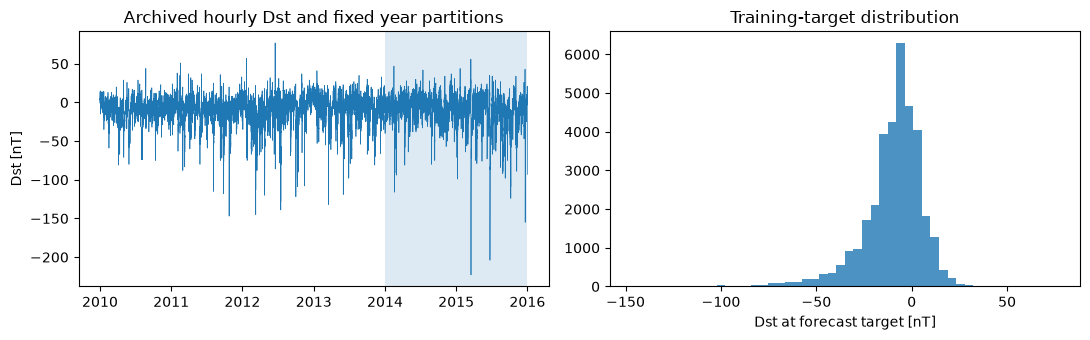

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(frame["timestamp"], frame["Dst"], linewidth=0.5)
axes[0].axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2015-01-01"), alpha=0.15)
axes[0].axvspan(pd.Timestamp("2015-01-01"), frame["timestamp"].max(), alpha=0.15)
axes[0].set(title="Archived hourly Dst and fixed year partitions", ylabel="Dst [nT]")
axes[1].hist(y_train, bins=50, alpha=0.8)
axes[1].set(title="Training-target distribution", xlabel="Dst at forecast target [nT]")
plt.tight_layout()
plt.show()

## Establish the persistence baseline

In [7]:
def regression_metrics(y_true, y_prediction):
    return {
        "mae": float(mean_absolute_error(y_true, y_prediction)),
        "rmse": float(mean_squared_error(y_true, y_prediction) ** 0.5),
        "r2": float(r2_score(y_true, y_prediction)),
    }


persistence_metrics = regression_metrics(y_test, persistence_test)
print("persistence baseline:", persistence_metrics)

persistence baseline: {'mae': 6.307481288909912, 'rmse': 9.751627077152586, 'r2': 0.803195059299469}


## Define the PyTorch model

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)  # Prefer repeatable operations when available.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)


class DstRegressor(nn.Module):
    def __init__(self, number_inputs):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(number_inputs, 50),
            nn.ReLU(),
            nn.Linear(50, 30),
            nn.ReLU(),
            nn.Linear(30, 1),
        )

    def forward(self, values):
        return self.network(values).squeeze(1)


model = DstRegressor(x_train.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())  # Adam updates the model weights.
loss_function = nn.MSELoss()  # Mean-squared error for the continuous Dst target.
print(model)

DstRegressor(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=30, bias=True)
    (3): ReLU()
    (4): Linear(in_features=30, out_features=1, bias=True)
  )
)


## Train and restore the best validation state

epoch 1: loss=133.213, val_loss=56.399


epoch 2: loss=47.499, val_loss=50.615


epoch 3: loss=43.951, val_loss=48.904


epoch 4: loss=42.661, val_loss=47.484


epoch 5: loss=41.959, val_loss=47.747


epoch 6: loss=41.515, val_loss=46.171


epoch 7: loss=41.270, val_loss=48.310


epoch 8: loss=40.901, val_loss=46.428


epoch 9: loss=40.785, val_loss=45.534


epoch 10: loss=40.489, val_loss=48.487


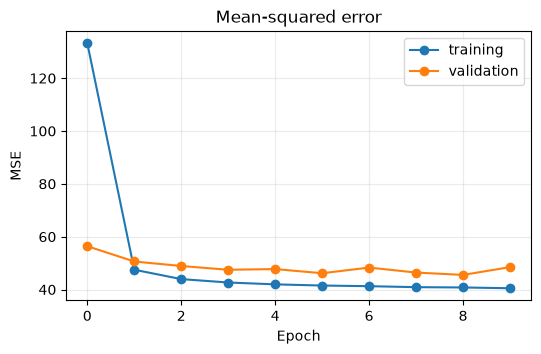

In [9]:
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
x_validation_tensor = torch.from_numpy(x_validation).to(DEVICE)
y_validation_tensor = torch.from_numpy(y_validation).to(DEVICE)
training_loss, validation_loss = [], []
best_state, best_validation, stale_epochs = None, float("inf"), 0

for epoch in range(EPOCHS):
    model.train()
    total = 0.0
    for features, target in train_loader:
        optimizer.zero_grad()
        loss = loss_function(model(features.to(DEVICE)), target.to(DEVICE))
        loss.backward()
        optimizer.step()
        total += loss.item() * len(target)
    training_loss.append(total / len(train_loader.dataset))
    model.eval()
    with torch.no_grad():
        current_validation = loss_function(
            model(x_validation_tensor), y_validation_tensor
        ).item()
    validation_loss.append(current_validation)
    print(
        f"epoch {epoch + 1}: loss={training_loss[-1]:.3f}, "
        f"val_loss={current_validation:.3f}"
    )
    if current_validation < best_validation:
        best_validation = current_validation
        best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= 3:
            break

model.load_state_dict(best_state)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(training_loss, marker="o", label="training")
ax.plot(validation_loss, marker="o", label="validation")
ax.set(title="Mean-squared error", xlabel="Epoch", ylabel="MSE")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Evaluate the untouched test year

In [10]:
model.eval()
with torch.no_grad():
    predictions = model(torch.from_numpy(x_test).to(DEVICE)).cpu().numpy()

model_metrics = regression_metrics(y_test, predictions)
persistence_skill = 1.0 - (
    model_metrics["rmse"] ** 2 / persistence_metrics["rmse"] ** 2
)
print("model:", model_metrics)
print(f"persistence skill: {persistence_skill:.4f}")
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "model_rmse": model_metrics["rmse"],
            "persistence_rmse": persistence_metrics["rmse"],
            "persistence_skill": persistence_skill,
            "prediction_shape": list(predictions.shape),
        },
        sort_keys=True,
    )
)
assert predictions.shape == y_test.shape
assert np.isfinite(predictions).all()

model: {'mae': 5.530179500579834, 'rmse': 8.194559329964283, 'r2': 0.8610261678695679}
persistence skill: 0.2938
HELIO_RESULT {"model_rmse": 8.194559329964283, "persistence_rmse": 9.751627077152586, "persistence_skill": 0.2938498776214198, "prediction_shape": [8755], "split_signature": "27777a6eb4e16cdf"}


## Diagnose timing and residual errors

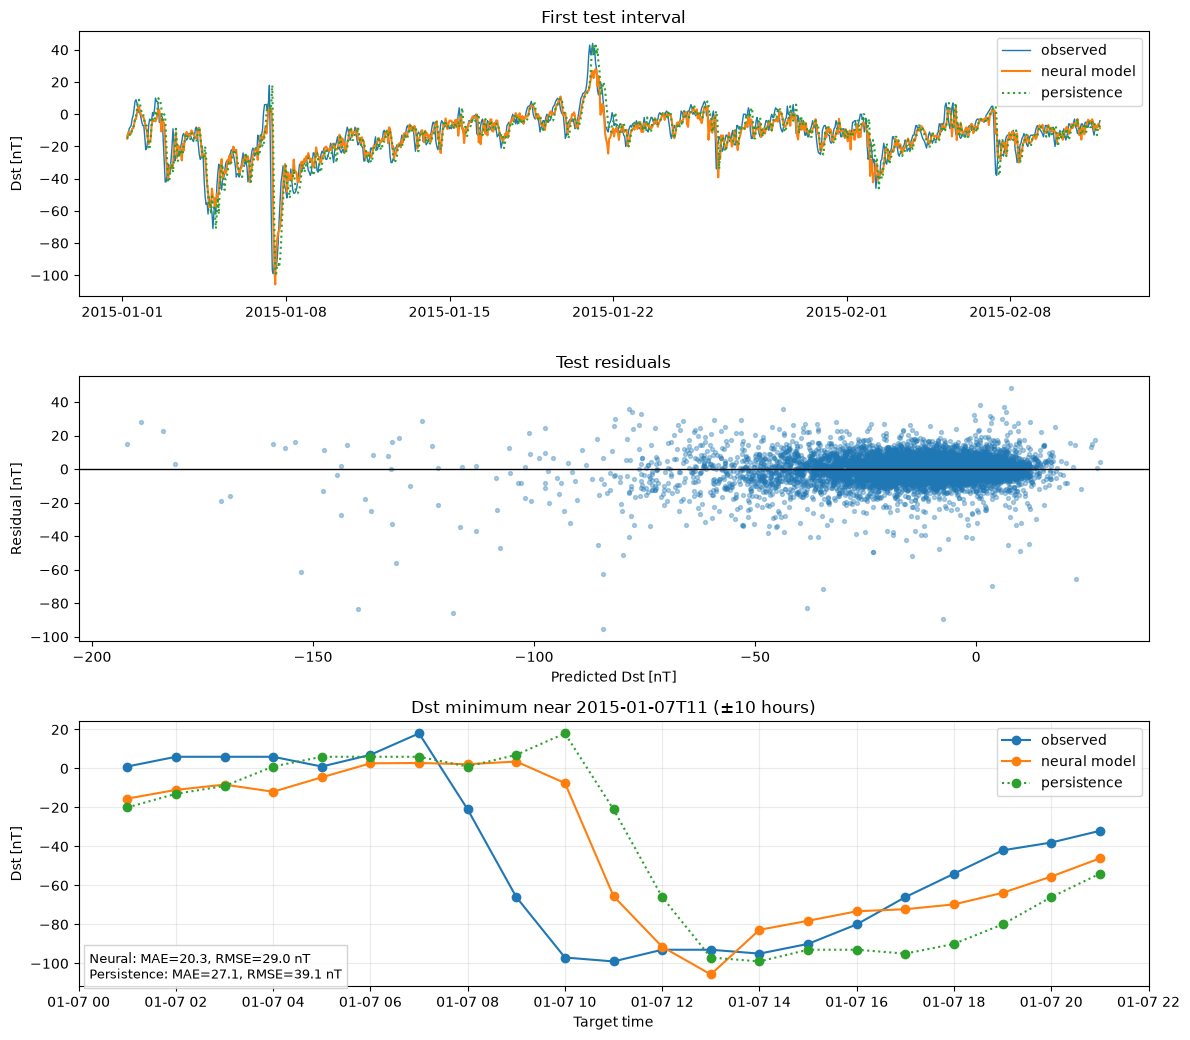

Focused interval center: 2015-01-07T11
Focused neural-model metrics: {'mae': 20.32349395751953, 'rmse': 28.981730000607712, 'r2': 0.5157457590103149}
Focused persistence metrics: {'mae': 27.14285659790039, 'rmse': 39.116431519806994, 'r2': 0.1178482174873352}
Largest absolute test errors:
2015-06-23T03 observed=-180.0 predicted=-84.4 persistence=-101.0
2015-01-07T10 observed=-97.0 predicted=-7.5 persistence=18.0
2015-06-23T04 observed=-204.0 predicted=-118.4 persistence=-131.0
2015-03-17T22 observed=-223.0 predicted=-139.8 persistence=-165.0
2015-06-22T20 observed=-121.0 predicted=-38.2 persistence=-41.0
2015-06-22T21 observed=-106.0 predicted=-34.6 persistence=-8.0
2015-01-07T09 observed=-66.0 predicted=3.5 persistence=7.0
2015-03-17T08 observed=-43.0 predicted=22.7 persistence=56.0


In [11]:
display_count = min(1000, len(y_test))
worst = np.argsort(np.abs(y_test - predictions))[-8:][::-1]

# Locate the strongest Dst decrease around 7 January 2015, then show a
# focused 20-hour interval around the observed minimum.
event_search = (
    (time_test >= np.datetime64("2015-01-05"))
    & (time_test < np.datetime64("2015-01-10"))
)
event_candidates = np.flatnonzero(event_search)
event_center_index = event_candidates[np.argmin(y_test[event_candidates])]
event_center = time_test[event_center_index]
event_window = (
    (time_test >= event_center - np.timedelta64(10, "h"))
    & (time_test <= event_center + np.timedelta64(10, "h"))
)
event_model_metrics = regression_metrics(y_test[event_window], predictions[event_window])
event_persistence_metrics = regression_metrics(
    y_test[event_window], persistence_test[event_window]
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10.5))
axes[0].plot(time_test[:display_count], y_test[:display_count], label="observed", linewidth=1)
axes[0].plot(time_test[:display_count], predictions[:display_count], label="neural model")
axes[0].plot(
    time_test[:display_count],
    persistence_test[:display_count],
    label="persistence",
    linestyle=":",
)
axes[0].set(title="First test interval", ylabel="Dst [nT]")
axes[0].legend()
axes[1].scatter(predictions, y_test - predictions, s=8, alpha=0.35)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Predicted Dst [nT]", ylabel="Residual [nT]", title="Test residuals")
axes[2].plot(time_test[event_window], y_test[event_window], label="observed", marker="o")
axes[2].plot(
    time_test[event_window], predictions[event_window], label="neural model", marker="o"
)
axes[2].plot(
    time_test[event_window],
    persistence_test[event_window],
    label="persistence",
    marker="o",
    linestyle=":",
)
axes[2].set(
    title=f"Dst minimum near {str(event_center)[:13]} (±10 hours)",
    xlabel="Target time",
    ylabel="Dst [nT]",
)
axes[2].legend()
axes[2].grid(alpha=0.25)
axes[2].text(
    0.01,
    0.03,
    (
        f"Neural: MAE={event_model_metrics['mae']:.1f}, "
        f"RMSE={event_model_metrics['rmse']:.1f} nT\n"
        f"Persistence: MAE={event_persistence_metrics['mae']:.1f}, "
        f"RMSE={event_persistence_metrics['rmse']:.1f} nT"
    ),
    transform=axes[2].transAxes,
    fontsize=9,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
plt.tight_layout()
plt.show()

print(f"Focused interval center: {event_center}")
print("Focused neural-model metrics:", event_model_metrics)
print("Focused persistence metrics:", event_persistence_metrics)

print("Largest absolute test errors:")
for index in worst:
    print(
        str(time_test[index]),
        f"observed={y_test[index]:.1f}",
        f"predicted={predictions[index]:.1f}",
        f"persistence={persistence_test[index]:.1f}",
    )

## Try it yourself

Change one choice at a time and keep the data split and evaluation unchanged:

- compare three- and six-hour input histories.
- change the forecast horizon while keeping 2015 as the final test year.
- add one solar-wind variable and fit its scaling on training years only.
- go one step further and rebuild the data-loading stage with NASA CDAWeb's official [`cdasws` Python API](https://cdaweb.gsfc.nasa.gov/WebServices/py/cdasws/), then reproduce the hourly OMNI variables and time range used here.